# Neural Network

In [1]:
# Packages for data processing and plotting.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
from tqdm.notebook import tqdm
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Packages to evaluate model performance.
from sklearn import metrics
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import copy

### Load Data

In [2]:
# Load data in dataframe
train_student_data = pd.read_csv("../data/train.csv")
submission_student_data = pd.read_csv("../data/test.csv")

In [3]:
# Drop ID column (redundant)
id_data = submission_student_data["id"] # Save ID for submission
train_student_data = train_student_data.drop(columns=["id"])
submission_student_data = submission_student_data.drop(columns=["id"])  

### Preprocess

In [4]:
tabular_columns = train_student_data.select_dtypes(include=['str']).columns.tolist()
tabular_columns

['gender',
 'course',
 'internet_access',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty']

In [5]:
# for column in tabular_columns:
#     mapping_store = {}
#     unique_vals = train_student_data[column].unique().tolist()
#     for val in unique_vals:
#         mapping_store[val] = len(mapping_store)
#     train_student_data[column] = train_student_data[column].map(mapping_store)

oe = OrdinalEncoder()
train_student_data[tabular_columns] = oe.fit_transform(train_student_data[tabular_columns])

In [6]:
submission_student_data[tabular_columns] = oe.transform(submission_student_data[tabular_columns])

In [7]:
features = list(train_student_data.columns)
features.remove("exam_score")

X = train_student_data[features]
y = train_student_data["exam_score"]
X_submission = submission_student_data[features]

In [8]:
numeric_columns = [c for c in X.select_dtypes(include=['number']).columns if c not in tabular_columns]
numeric_columns

['age', 'study_hours', 'class_attendance', 'sleep_hours']

In [9]:
scaler = StandardScaler()
X[numeric_columns] = scaler.fit_transform(X[numeric_columns])
X_submission[numeric_columns] = scaler.transform(X_submission[numeric_columns])

In [10]:
# print("Previous Data Types:")
# print(f" - Features Training: {type(X)}")
# print(f" - Label: {type(y)}")
# print(f" - Features Submission: {type(X_submission)}")
# print()

# # Convert data to tensors.
# X_tensor = torch.tensor(X.to_numpy(), dtype=torch.float32)
# y_tensor = torch.tensor(y.to_numpy(), dtype=torch.float32).reshape(-1, 1)
# X_submission_tensor = torch.tensor(X_submission.to_numpy(), dtype=torch.float32)

# print("New Data Types:")
# print(f" - Features Training: {type(X_tensor)}")
# print(f" - Label: {type(y_tensor)}")
# print(f" - Features Submission: {type(X_submission_tensor)}")

### Train/Validation Split

In [11]:
# seed = 100
# test_size = 0.2

# X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=test_size, random_state=seed)

In [12]:
cat_cols = ['gender', 'course', 'internet_access',
            'sleep_quality', 'study_method',
            'facility_rating', 'exam_difficulty']
num_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

X_cat = torch.tensor(X[cat_cols].to_numpy(), dtype=torch.long)
X_num = torch.tensor(X[num_cols].to_numpy(), dtype=torch.float32)
y_tensor = torch.tensor(y.to_numpy(), dtype=torch.float32).reshape(-1, 1)

X_sub_cat = torch.tensor(X_submission[cat_cols].to_numpy(), dtype=torch.long)
X_sub_num = torch.tensor(X_submission[num_cols].to_numpy(), dtype=torch.float32)

In [13]:
seed = 100
test_size = 0.2

dataset = TensorDataset(X_cat, X_num, y_tensor)
train_size = int((1 - test_size) * len(dataset))
test_size_n = len(dataset) - train_size

In [14]:
torch.manual_seed(seed)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size_n])

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Model Definition

In [15]:
# class StudentScoreNet(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.emb_gender = nn.Embedding(X['gender'].nunique(), 2)
#         self.embed_course = nn.Embedding(X['course'].nunique(), 4)
#         self.embed_internet_access = nn.Embedding(X['internet_access'].nunique(), 2)
#         self.sleep_quality = nn.Embedding(X['sleep_quality'].nunique(), 2)
#         self.study_method = nn.Embedding(X['study_method'].nunique(), 3)
#         self.facility_rating = nn.Embedding(X['facility_rating'].nunique(), 2)
#         self.exam_difficulty = nn.Embedding(X['exam_difficulty'].nunique(), 2)

#         # Total concat dim: (2+4+2+2+3+2+2) + 4 numeric = 21
#         self.dense = nn.Sequential(
#             nn.Linear(21, 64),
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Dropout(0.3),

#             nn.Linear(64, 32),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.Dropout(0.3),

#             nn.Linear(32, 1)
#         )
    
#     def forward(self, x_cat, x_num):
#         # x_cat: (batch, 7) — integer-encoded
#         # x_num: (batch, 4) — standardized numerics

#         # Each embedding expects a 1D LongTensor, so index each column
#         embs = [
#             self.emb_gender(x_cat[:, 0]),
#             self.emb_course(x_cat[:, 1]),
#             self.emb_internet(x_cat[:, 2]),
#             self.emb_sleep_quality(x_cat[:, 3]),
#             self.emb_study_method(x_cat[:, 4]),
#             self.emb_facility(x_cat[:, 5]),
#             self.emb_exam_diff(x_cat[:, 6]),
#         ]

#         # Concatenate all embeddings + numeric features → (batch, 21)
#         x = torch.cat(embs + [x_num], dim=1)

#         return self.dense(x)


In [16]:
class StudentScoreNet(nn.Module):
    def __init__(self, cat_features, cat_dims, emb_dims, num_numeric, num_output=1):
        """
        Args:
            cat_features: list of categorical column names
                          e.g. ['gender', 'course', 'internet_access', ...]
            cat_dims:     list of ints — number of unique categories per feature
                          e.g. [3, 7, 2, 3, 5, 3, 3]
            emb_dims:     list of ints — embedding dimension per feature
                          e.g. [2, 4, 2, 2, 3, 2, 2]
            num_numeric:  int — number of numeric features (4 in our case)
            num_output:   int — output size (1 for single-target regression)
        """
        super().__init__()

        # Create one embedding layer per categorical feature
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_categories, emb_dim)
            for num_categories, emb_dim in zip(cat_dims, emb_dims)
        ])

        # Total input dim to dense layers = sum of all embedding dims + numeric features
        total_emb_dim = sum(emb_dims)
        concat_dim = total_emb_dim + num_numeric

        # Dense layers
        self.dense = nn.Sequential(
            nn.Linear(concat_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.15),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.15),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.15),

            nn.Linear(64, num_output)

        )

    def forward(self, x_cat, x_num):
        """
        Args:
            x_cat: (batch, num_cat_features) — LongTensor of label-encoded ints
            x_num: (batch, num_numeric)      — FloatTensor of standardized numerics
        Returns:
            (batch, num_output) — predicted exam score(s)
        """
        # Pass each categorical column through its embedding layer
        embs = [
            emb_layer(x_cat[:, i])
            for i, emb_layer in enumerate(self.embeddings)
        ]

        # Concatenate all embeddings + numeric features → (batch, concat_dim)
        x = torch.cat(embs + [x_num], dim=1)

        return self.dense(x)

In [17]:
cat_features = ['gender', 'course', 'internet_access',
                'sleep_quality', 'study_method',
                'facility_rating', 'exam_difficulty']

cat_dims = [3, 7, 2, 3, 5, 3, 3]
emb_dims = [2, 4, 2, 2, 3, 2, 2]
num_numeric = 4  
num_output = 1

In [18]:
model = StudentScoreNet(cat_features, cat_dims, emb_dims, num_numeric, num_output)
model

StudentScoreNet(
  (embeddings): ModuleList(
    (0): Embedding(3, 2)
    (1): Embedding(7, 4)
    (2): Embedding(2, 2)
    (3): Embedding(3, 2)
    (4): Embedding(5, 3)
    (5-6): 2 x Embedding(3, 2)
  )
  (dense): Sequential(
    (0): Linear(in_features=21, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [19]:
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


Total parameters: 47,816


In [20]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.best_weights = None
        self.should_stop = False

    def step(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

### Train

In [21]:
early_stopping = EarlyStopping()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
num_epochs = 50

train_losses = []
test_losses = []

epoch_bar = tqdm(range(num_epochs), desc="Training", unit="epoch")

for epoch in epoch_bar:
    # --- Training ---
    model.train()
    epoch_train_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
    for x_cat_batch, x_num_batch, y_batch in train_bar:
        optimizer.zero_grad()
        y_pred = model(x_cat_batch, x_num_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * len(y_batch)
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_train_loss /= len(train_dataset)
    train_losses.append(epoch_train_loss)

    # --- Evaluation ---
    model.eval()
    epoch_test_loss = 0.0
    all_preds = []
    all_labels = []
    val_bar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
    with torch.no_grad():
        for x_cat_batch, x_num_batch, y_batch in val_bar:
            y_pred = model(x_cat_batch, x_num_batch)
            loss = criterion(y_pred, y_batch)
            epoch_test_loss += loss.item() * len(y_batch)
            all_preds.append(y_pred)
            all_labels.append(y_batch)
            val_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_test_loss /= len(test_dataset)
    test_losses.append(epoch_test_loss)

    early_stopping.step(epoch_test_loss, model)
    if early_stopping.should_stop:
        print(f"Early stopping at epoch {epoch+1}")
        model.load_state_dict(early_stopping.best_weights)
        break

    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    r2 = metrics.r2_score(labels, preds)

    epoch_bar.set_postfix(
        train_loss=f"{epoch_train_loss:.4f}",
        val_loss=f"{epoch_test_loss:.4f}",
        R2=f"{r2:.4f}"
    )

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [Train]:   0%|          | 0/1969 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/493 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/1969 [00:00<?, ?it/s]

Epoch 2/50 [Val]:   0%|          | 0/493 [00:00<?, ?it/s]

...

Epoch 35/50 [Train]:   0%|          | 0/1969 [00:00<?, ?it/s]

Epoch 35/50 [Val]:   0%|          | 0/493 [00:00<?, ?it/s]

Epoch 36/50 [Train]:   0%|          | 0/1969 [00:00<?, ?it/s]

Epoch 36/50 [Val]:   0%|          | 0/493 [00:00<?, ?it/s]

Early stopping at epoch 36


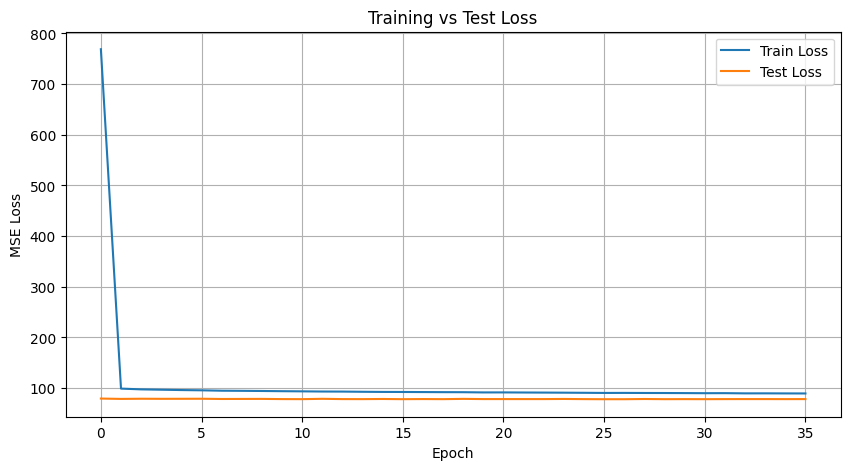

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.grid(True)
plt.show()

### Evaluate

In [23]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for x_cat_batch, x_num_batch, y_batch in test_loader:
        y_pred = model(x_cat_batch, x_num_batch)
        all_preds.append(y_pred)
        all_labels.append(y_batch)

preds = torch.cat(all_preds).numpy()
labels = torch.cat(all_labels).numpy()

r2 = metrics.r2_score(labels, preds)
rmse = np.sqrt(metrics.mean_squared_error(labels, preds))
mae = metrics.mean_absolute_error(labels, preds)

print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

R²:   0.7818
RMSE: 8.8301
MAE:  7.0508


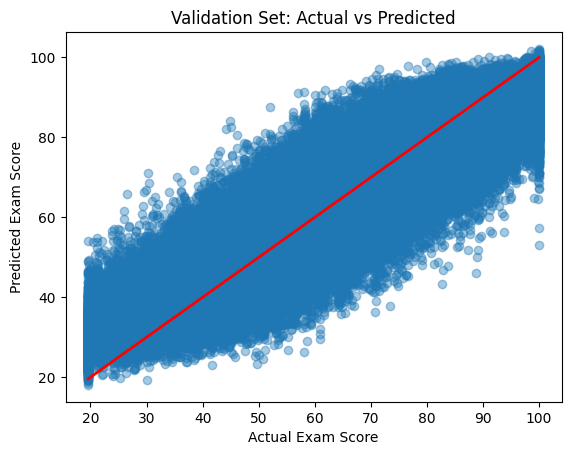

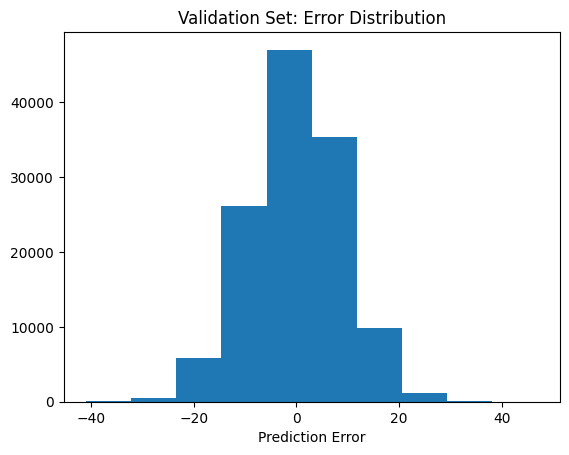

Metrics saved to ../metrics/neural_network_metrics.csv


,MAE,MSE,RMSE,R2
0,7.050828,77.971062,8.830122,0.781783


In [24]:
# Actual vs Predicted
plt.scatter(labels, preds, alpha=0.4)
plt.plot([labels.min(), labels.max()], [labels.min(), labels.max()], "r", lw=2)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Validation Set: Actual vs Predicted")
plt.show()

# Error distribution
plt.hist(labels - preds)
plt.xlabel("Prediction Error")
plt.title("Validation Set: Error Distribution")
plt.show()

# Metrics
pd.set_option("float_format", "{:f}".format)
res_metrics = pd.DataFrame({
    "MAE": [metrics.mean_absolute_error(labels, preds)],
    "MSE": [metrics.mean_squared_error(labels, preds)],
    "RMSE": [np.sqrt(metrics.mean_squared_error(labels, preds))],
    "R2": [metrics.r2_score(labels, preds)],
})
res_metrics.to_csv("../metrics/neural_network_metrics.csv", index=False)
print("Metrics saved to ../metrics/neural_network_metrics.csv")
res_metrics

### Generate Submission

In [ ]:
# Generate submission predictions using contest test set
model.eval()
with torch.no_grad():
    y_submission_pred = model(X_sub_cat, X_sub_num).numpy().flatten()

submission = pd.DataFrame({
    "id": id_data,
    "exam_score": y_submission_pred
})
submission.to_csv("../submission/neural_network_linear_embedded_submission.csv", index=False)
print("Submission saved to ../submission/neural_network_linear_embedded_submission.csv")
submission

Submission saved to ../submission/neural_network_submission.csv


,id,exam_score
0,630000,72.575653
1,630001,69.576088
2,630002,87.477173
3,630003,54.526112
4,630004,48.013393
...,...,...
269995,899995,60.495705
269996,899996,39.096176
269997,899997,90.874672
269998,899998,54.495056


In [ ]:
# Save model
torch.save(model.state_dict(), "../models/neural_network_linear_embedded.pt")
print("Model saved to ../models/neural_network_linear_embedded.pt")

Model saved to ../models/neural_network.pt
